# Cross-validation of NK cell annotation in the external scRNA-seq dataset (Figure S4)

**Manuscript Context:** This notebook contains the code and workflows used to generate Figure S4a–g for our study on Extranodal NK/T-cell lymphoma (ENKTCL).

**Objective:**
The goal of this analysis is to validate our computational framework and NK cell subpopulation definitions against an independent external single-cell RNA-seq dataset. Specifically, we:
1.  Visualize the UMAP projection of the external dataset to confirm the distinction between Malignant NK cells, Normal NK cells, and other immune lineages, as well as the separation of malignant subclusters.
2.  Map the tissue origin (PBMC vs. Tumor) onto the UMAP to evaluate compartment-specific enrichment and re-annotate cells using our CNV-based criteria to confirm consistency in genomic classification.
3.  Generate a heatmap to visualize the concordance of Copy Number Variations (CNVs) across chromosomal regions—particularly the focal alterations in chr6p21—and compare the enrichment scores of MHC Class I signatures and expression levels of LMP-1 across the defined CNV statuses.

In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
import muon as mu
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib as mpl
import matplotlib.ticker as ticker
import sys
mpl.rcParams['font.family'] = 'Arial'
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14
import os
print(sys.version)

3.11.11 (main, Dec 11 2024, 16:28:39) [GCC 11.2.0]


In [901]:
figPath = "./figures/figS4"
NKPath = './data/GSE203663_NKTCL_NK.h5ad'
datPath = "./data/GSE203663_NKTCL.h5ad"
os.makedirs(figPath, exist_ok=True)

In [ ]:
adata_exter = sc.read_h5ad(datPath)
adata_exter_NK = sc.read_h5ad(NKPath)

#### **Fig. S4a** UMAP projection of quality-controlled cells from the external single-cell RNA-seq dataset.

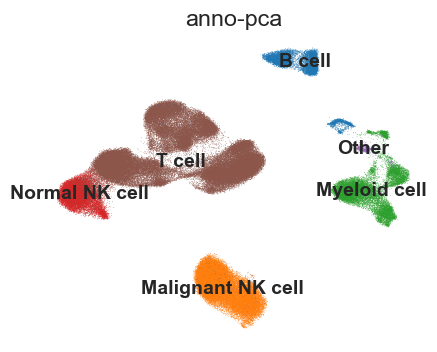

In [902]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sc.pl.umap(adata_exter, color=['anno-pca'], ax=ax, show=False, legend_loc='on data')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f"{figPath}/FigS4a.png", dpi=150, bbox_inches='tight')

#### **Fig. S4b** UMAP projection of NK cells (Total NK cells: n = 43,603) from the external dataset, colored by the original subcluster annotations

In [ ]:
def clu(adata, key_added="leiden-1", 
        n_neighbors=50, n_pcs=30, 
        rep='X_pca_harmony', 
        do_har=False, 
        max_iter=20, 
        do_scrublet=False, 
        har_key='batch', 
        resolution=1):
    # Computing the neighborhood graph
    if do_scrublet:
        n0 = adata.shape[0]
        print("{0} Cell number: {1}".format(key_added, n0))
        sc.external.pp.scrublet(adata)
        adata = adata[adata.obs['predicted_doublet']==False,:].copy()
        print("{0} Cells retained after scrublet, {1} cells reomved.".format(adata.shape[0], n0-adata.shape[0]))
    else:
        print("Ignoring processing doublet cells...")
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    
    sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
    sc.pp.pca(adata, svd_solver='arpack', use_highly_variable=True)
    if do_har and len(adata.obs[har_key].cat.categories) > 1:
        sc.external.pp.harmony_integrate(adata, key=har_key,max_iter_harmony=max_iter)
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, use_rep=rep)
    else:
        print("Evaluating neighbors only...")
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, use_rep=rep)
    # Run UMAP
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=resolution, key_added=key_added)
    sc.pl.umap(adata, color=key_added, legend_fontoutline=True, palette=sc.pl.palettes.default_20, legend_loc="on data")
    return adata

Ignoring processing doublet cells...


2026-04-12 04:08:07,568 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO	harmonypy:harmony.py:_cluster_kmeans()- Computing initial centroids with sklearn.KMeans...
2026-04-12 04:08:11,016 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO	harmonypy:harmony.py:_cluster_kmeans()- sklearn.KMeans initialization complete.
2026-04-12 04:08:11,163 - harmonypy - INFO - Iteration 1 of 20
INFO	harmonypy:harmony.py:harmonize()- Iteration 1 of 20
2026-04-12 04:08:19,714 - harmonypy - INFO - Iteration 2 of 20
INFO	harmonypy:harmony.py:harmonize()- Iteration 2 of 20
2026-04-12 04:08:28,157 - harmonypy - INFO - Iteration 3 of 20
INFO	harmonypy:harmony.py:harmonize()- Iteration 3 of 20
2026-04-12 04:08:36,672 - harmonypy - INFO - Converged after 3 iterations
INFO	harmonypy:harmony.py:harmonize()- Converged after 3 iterations


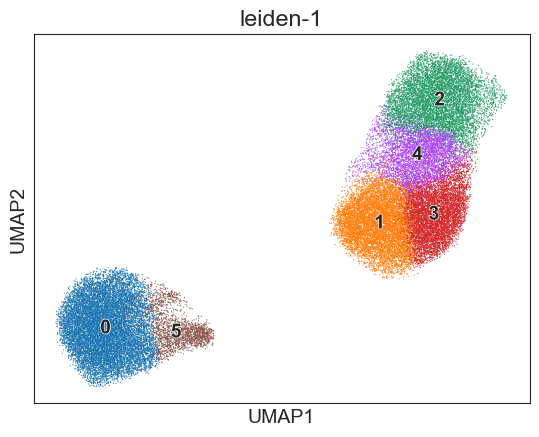

In [907]:
adata_exter_NK = clu(adata_exter_NK, do_har=True, do_scrublet=False)

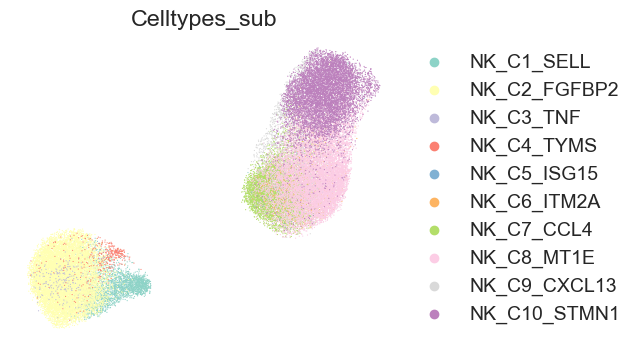

In [908]:
palette=[sc.pl.palettes.cm.Set3.colors]
for i, obs in enumerate(['Celltypes_sub']):
  fig, ax = plt.subplots(1, 1, figsize=(5, 4))
  sc.pl.umap(adata_exter_NK, color=obs, ax=ax, show=False, palette=palette[i])
  ax.spines['right'].set_visible(False)
  ax.spines['top'].set_visible(False)
  ax.spines['left'].set_visible(False)
  ax.spines['bottom'].set_visible(False)
  ax.set_xlabel("")
  ax.set_ylabel("")
  fig.savefig(f"{figPath}/FigS4b.png", dpi=150, bbox_inches='tight')

#### **Fig. S4c** UMAP projection of NK cells (Total NK cells: n = 43,603) from the external dataset, colored by tissue type

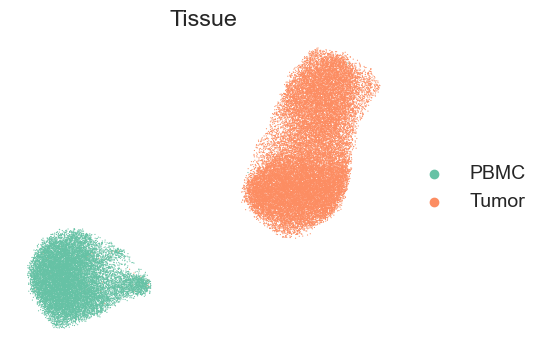

In [911]:
palette=[sc.pl.palettes.cm.Set2.colors]
for i, obs in enumerate(['Tissue']):
  fig, ax = plt.subplots(1, 1, figsize=(5, 4))
  sc.pl.umap(adata_exter_NK, color=obs, ax=ax, show=False, palette=palette[i])
  ax.spines['right'].set_visible(False)
  ax.spines['top'].set_visible(False)
  ax.spines['left'].set_visible(False)
  ax.spines['bottom'].set_visible(False)
  ax.set_xlabel("")
  ax.set_ylabel("")
  fig.savefig(f"{figPath}/FigS4c.png", dpi=150, bbox_inches='tight')

#### **Fig. S4d** UMAP projection of NK cells (Total NK cells: n = 43,603) from the external dataset, colored by CNV status

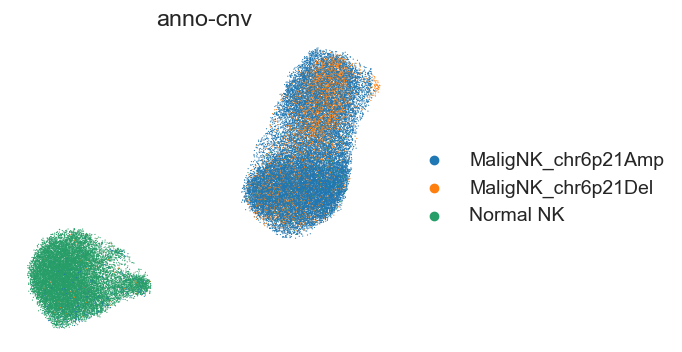

In [910]:
palette=[sc.pl.palettes.default_20]
for i, obs in enumerate(['anno-cnv']):
  fig, ax = plt.subplots(1, 1, figsize=(5, 4))
  sc.pl.umap(adata_exter_NK, color=obs, ax=ax, show=False, palette=palette[i])
  ax.spines['right'].set_visible(False)
  ax.spines['top'].set_visible(False)
  ax.spines['left'].set_visible(False)
  ax.spines['bottom'].set_visible(False)
  ax.set_xlabel("")
  ax.set_ylabel("")
  fig.savefig(f"{figPath}/FigS4d.png", dpi=150, bbox_inches='tight')

#### **Fig. S4e** Heatmap of CNVs across CNV statuses (rows: MaligNK_chr6p21Amp, MaligNK_chr6p21Del, Normal NK; columns: chromosomal regions chr1–chr22).

In [ ]:
import infercnvpy as cnv 
import pandas as pd
chrom = pd.read_csv("/home/rzh/gene_pos.txt", sep='\t', header=None)
chrom.columns = ["symbol", "ensg", "chromosome", "start", "end"]
chrom['ensg'] = [name.split('.')[0] for name in chrom['ensg']]
chrom.index = chrom['symbol']
chrom_ensg = chrom.copy()
chrom_ensg.index = chrom_ensg['ensg']
var_names = list(adata_exter.var_names[adata_exter.var_names.isin(chrom['symbol'])])
chrom_var_names = chrom.loc[var_names, :]
chrom_var_names.index = var_names
adata_exter_cnv = adata_exter[:, adata_exter.var_names.isin(chrom['symbol'])]
adata_exter_cnv.var = pd.concat([adata_exter_cnv.var, chrom_var_names], axis=1)
adata_exter_cnv.var_names_make_unique()
adata_exter_cnv

In [ ]:
cnv.tl.infercnv(adata_exter_cnv,reference_key="anno-pca", reference_cat=['Normal NK cell'], layer='Raw')

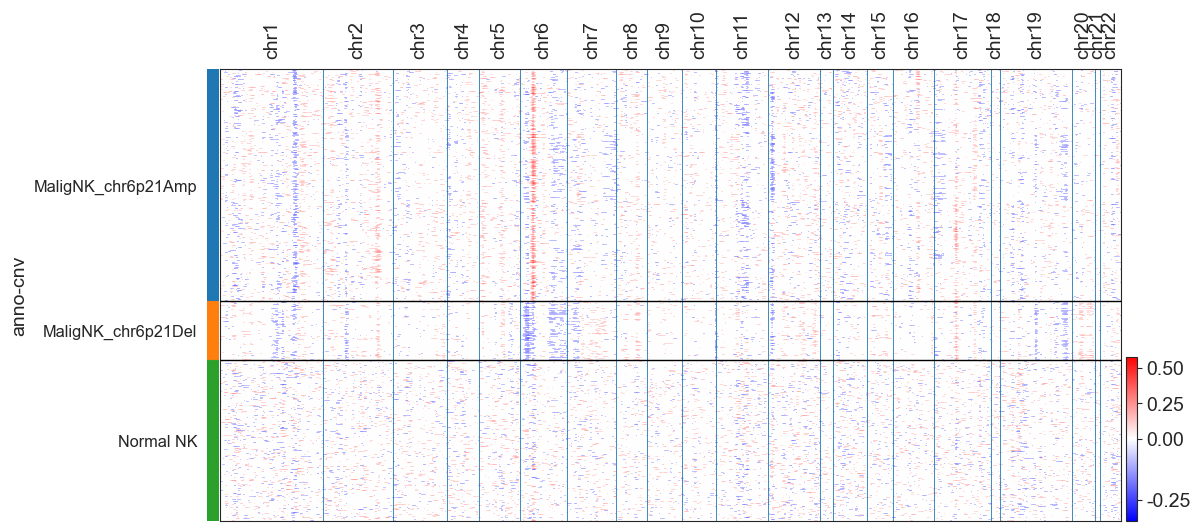

In [ ]:
adata_exter_cnv.obs['anno-cnv'] = adata_exter_NK.obs['anno-cnv']
ax = cnv.pl.chromosome_heatmap(adata_exter_cnv, groupby='anno-cnv', show = False)
fig = ax['heatmap_ax'].get_figure()
fig.set_size_inches(12, 6)
fig.savefig(f"{figPath}/FigS4e.pdf", bbox_inches='tight')
plt.show()

#### **Fig. S3f** Violin plots show the distribution of MHC Class I signature enrichment scores 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np
from scipy import stats
from typing import List, Optional, Tuple, Dict, Any, Union

def plot_violin_stats(
    adata: sc.AnnData, 
    gene: str, 
    groupby: str, 
    ax: Optional[plt.Axes] = None, 
    figsize: Tuple[int, int] = (4, 5),
    jitter: float = 0.4,
    point_size: float = 1,
    order: Optional[List[str]] = None,
    show_p_value: bool = True,
    method: str = 'auto',
    comparisons: Optional[List[Tuple[str, str]]] = None
):
    """
    Plot violin plots with statistical significance markers.
    
    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes object.
    stats_results : List[Dict] or Dict
        Detailed statistical results. 
        If pairwise comparisons: List of dicts containing 'group1', 'group2', 'statistic', 'pvalue', 'mean1', 'mean2', 'direction'.
        If global test: Dict containing 'statistic', 'pvalue', 'method'.
    method_name : str
        Name of the statistical method used.
    """
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    if gene not in adata.var_names and gene not in adata.obs.columns:
        raise ValueError(f"Gene '{gene}' not found.")
    if groupby not in adata.obs.columns:
        raise ValueError(f"Group column '{groupby}' not found.")
    
    # Handle categories and order
    all_categories = list(adata.obs[groupby].astype('category').cat.categories)
    if order:
        categories = [c for c in order if c in all_categories]
    else:
        categories = all_categories
        
    if len(categories) < 2:
        raise ValueError("Need at least 2 groups for statistical testing.")
    
    # Extract data efficiently
    values_dict = {}
    for cat in categories:
        mask = adata.obs[groupby] == cat
        idx = np.where(mask)[0]
        if len(idx) > 0:
            if gene in adata.var_names:
                vals = adata[idx, gene].X.toarray().flatten() if hasattr(adata[idx, gene].X, "toarray") else adata[idx, gene].X.flatten()
            else:
                vals = adata.obs.loc[mask, gene].values
            values_dict[cat] = vals
        else:
            values_dict[cat] = np.array([])

    valid_groups = [g for g in categories if len(values_dict[g]) > 0]
    if len(valid_groups) < 2:
        raise ValueError("Less than 2 groups contain data.")
        
    group_data_map = {g: values_dict[g] for g in valid_groups}

    # Determine comparisons to perform
    tests_to_run = []
    global_stat_name = ""
    global_result = {}
    stats_results = [] # To store detailed results

    if comparisons:
        for g1, g2 in comparisons:
            if g1 not in valid_groups or g2 not in valid_groups:
                print(f"Warning: Skipping comparison ({g1}, {g2}) as one group is missing or empty.")
                continue
            tests_to_run.append((g1, g2))
    else:
        if len(valid_groups) == 2:
            tests_to_run.append((valid_groups[0], valid_groups[1]))
        else:
            # Global test for >2 groups
            group_data_list = [group_data_map[g] for g in valid_groups]
            stat_val, p_val = stats.kruskal(*group_data_list)
            global_stat_name = "Kruskal-Wallis"
            global_result = {
                'method': global_stat_name,
                'statistic': stat_val,
                'pvalue': p_val,
                'groups_compared': valid_groups
            }
            # For global test, we return the global_result as the main stats object if no pairwise requested
            if not tests_to_run: 
                stats_results = global_result 

    # Plot Violin
    try:
        sc.pl.violin(
            adata, keys=[gene], groupby=groupby, ax=ax, show=False, 
            order=order, ylabel=gene, xlabel=''
        )
    except Exception:
        df = adata.obs.copy()
        if gene in adata.var_names:
            df[gene] = adata[:, gene].X.toarray().flatten() if hasattr(adata[:, gene].X, "toarray") else adata[:, gene].X.flatten()
        sns.violinplot(x=groupby, y=gene, data=df, ax=ax, order=order, jitter=jitter)
        ax.set_ylabel(gene)
        ax.set_xlabel('')

    # Get X positions
    ax.figure.canvas.draw() 
    x_ticks = list(ax.get_xticks())
    tick_labels = [str(label.get_text()) for label in ax.get_xticklabels()]
    
    pos_map = {}
    if len(x_ticks) == len(tick_labels):
        for pos, label in zip(x_ticks, tick_labels):
            pos_map[label] = pos
    else:
        if len(x_ticks) == len(valid_groups):
            for i, g in enumerate(valid_groups):
                pos_map[g] = x_ticks[i]
        else:
            # Fallback mapping based on order if labels are missing
            # This assumes the plot drew them in the order of 'valid_groups' or 'order'
            # A robust fallback is difficult without labels, but we try:
            current_order = order if order else valid_groups
            for i, g in enumerate(current_order):
                if g in valid_groups and i < len(x_ticks):
                    pos_map[g] = x_ticks[i]

    def get_star(p):
        if p < 0.001: return "***"
        if p < 0.01: return "**"
        if p < 0.05: return "*"
        return "ns"

    y_min, y_max = ax.get_ylim()
    overall_max = max(np.max(v) if len(v)>0 else -np.inf for v in group_data_map.values())
    range_y = y_max - y_min
    if range_y == 0: range_y = 1
    
    current_height = overall_max
    
    # 1. Draw Pairwise Comparisons & Collect Stats
    if tests_to_run:
        stats_results = [] # Reset to list for pairwise
        for g1, g2 in tests_to_run:
            d1, d2 = group_data_map[g1], group_data_map[g2]
            stat_val, p_val = stats.mannwhitneyu(d1, d2, alternative='two-sided')
            
            # Calculate descriptive stats
            m1, m2 = np.mean(d1), np.mean(d2)
            med1, med2 = np.median(d1), np.median(d2)
            
            # Determine direction
            if m1 > m2: direction = f"{g1} > {g2}"
            elif m2 > m1: direction = f"{g2} > {g1}"
            else: direction = "Equal"
            
            res_dict = {
                'group1': g1, 'group2': g2,
                'statistic': stat_val, # U value
                'pvalue': p_val,
                'mean1': m1, 'mean2': m2,
                'median1': med1, 'median2': med2,
                'direction': direction,
                'method': 'Mann-Whitney U'
            }
            stats_results.append(res_dict)
            
            # Plotting logic
            if p_val < 0.05 and show_p_value:
                if g1 not in pos_map or g2 not in pos_map:
                    continue
                    
                x1, x2 = pos_map[g1], pos_map[g2]
                offset = range_y * 0.05
                bar_height = offset * 0.5
                y_line = current_height + offset
                
                ax.plot([x1, x2], [y_line, y_line], color='black', linewidth=1.2)
                ax.plot([x1, x1], [y_line, y_line - bar_height], color='black', linewidth=1.2)
                ax.plot([x2, x2], [y_line, y_line - bar_height], color='black', linewidth=1.2)
                
                p_str = f"p={p_val:.2e}" if p_val < 0.0001 else f"p={p_val:.3f}"
                star = get_star(p_val)
                # Optionally add direction to the plot text if space permits, otherwise just star/p
                ax.text((x1 + x2) / 2, y_line + bar_height*0.2, f"{star}\n({p_str})", 
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
                
                current_height = y_line + bar_height * 1.2

    # 2. Draw Global Significance
    if not comparisons and len(valid_groups) > 2 and global_stat_name:
        if global_result['pvalue'] < 0.05 and show_p_value:
            x_start, x_end = x_ticks[0], x_ticks[-1]
            offset = range_y * 0.05
            bar_height = offset * 0.5
            y_line = current_height + offset
            
            ax.plot([x_start, x_end], [y_line, y_line], color='black', linewidth=1.2)
            ax.plot([x_start, x_start], [y_line, y_line - bar_height], color='black', linewidth=1.2)
            ax.plot([x_end, x_end], [y_line, y_line - bar_height], color='black', linewidth=1.2)
            
            p_str = f"p={global_result['pvalue']:.2e}" if global_result['pvalue'] < 0.0001 else f"p={global_result['pvalue']:.3f}"
            star = get_star(global_result['pvalue'])
            ax.text((x_start + x_end) / 2, y_line + bar_height*0.2, f"{star}\n({p_str})\n(Global)", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
            
            current_height = y_line + bar_height * 1.2

    if current_height > overall_max:
        ax.set_ylim(y_min, current_height + range_y * 0.05)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    method_name = stats_results[0]['method'] if isinstance(stats_results, list) and stats_results else (global_result.get('method', 'Unknown'))
    
    return ax, stats_results, method_name

In [ ]:
def print_stat(stat, method):
    print(f"--- Statistical Analysis ({method}) ---")

    if isinstance(stat, list):
        #  pairwise comparisons
        for res in stat:
            print(f"Comparison: {res['group1']} vs {res['group2']}")
            print(f"  Direction: {res['direction']}")
            print(f"  Mean ({res['group1']}): {res['mean1']:.4f}")
            print(f"  Mean ({res['group2']}): {res['mean2']:.4f}")
            print(f"  Statistic (U): {res['statistic']:.2f}")
            print(f"  P-value: {res['pvalue']:.4e}")
            print("-" * 30)
    else:
        # Global test
        print(f"Global Test: {stat['method']}")
        print(f"  Statistic (H): {stat['statistic']:.2f}")
        print(f"  P-value: {stat['pvalue']:.4e}")

--- Statistical Analysis (Mann-Whitney U) ---
Comparison: MaligNK_chr6p21Amp vs MaligNK_chr6p21Del
  Direction: MaligNK_chr6p21Amp > MaligNK_chr6p21Del
  Mean (MaligNK_chr6p21Amp): 0.2655
  Mean (MaligNK_chr6p21Del): 0.1516
  Statistic (U): 115072279.00
  P-value: 0.0000e+00
------------------------------
Comparison: MaligNK_chr6p21Del vs Normal NK
  Direction: Normal NK > MaligNK_chr6p21Del
  Mean (MaligNK_chr6p21Del): 0.1516
  Mean (Normal NK): 0.3172
  Statistic (U): 2499950.00
  P-value: 0.0000e+00
------------------------------


/tmp/ipykernel_3335451/998297478.py:16: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



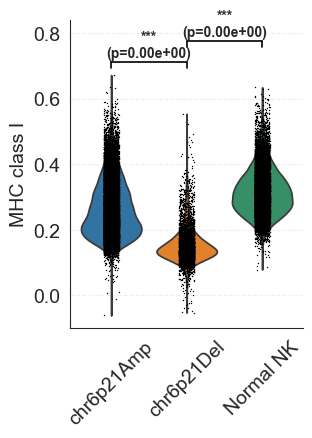

In [914]:
mhc_class_i = ['HLA-A', 'HLA-B', 'HLA-C', 'B2M', 'TAP1', 'TAP2', 'PSMB8', 'PSMB9', 'HLA-G', 'HLA-E',]
mhc_class_ii = ['HLA-DRA', 'HLA-DRB1', 'HLA-DPA1', 'HLA-DPB1', 'HLA-DQA1', 
                'HLA-DQB1', 'HLA-DMA', 'HLA-DMB', 'CD74']
sc.tl.score_genes(adata_exter_NK, gene_list=mhc_class_i, score_name='MHC class I')
fig, ax = plt.subplots(1, 1, figsize=(3, 4))
comparisons = [('MaligNK_chr6p21Amp', 'MaligNK_chr6p21Del'), ('MaligNK_chr6p21Del', 'Normal NK')]
ax, stat, method = plot_violin_stats(
    adata=adata_exter_NK,
    gene='MHC class I',
    groupby='anno-cnv',
    ax=ax,
    jitter=0.4,
    comparisons=comparisons,
)
ax.set_xlabel('')
ax.set_xticklabels(['chr6p21Amp', 'chr6p21Del', 'Normal NK'], rotation=45)
fig.savefig(f"{figPath}/FigS4f.png", dpi=150, bbox_inches='tight')
print_stat(stat, method)

#### **Fig. S4g** Violin plots show the distribution of LMP-1 expression across the CNV statuses. 

/tmp/ipykernel_3335451/2160694739.py:12: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



--- Statistical Analysis (Mann-Whitney U) ---
Comparison: MaligNK_chr6p21Amp vs MaligNK_chr6p21Del
  Direction: MaligNK_chr6p21Amp > MaligNK_chr6p21Del
  Mean (MaligNK_chr6p21Amp): 0.0327
  Mean (MaligNK_chr6p21Del): 0.0031
  Statistic (U): 69281417.00
  P-value: 8.7697e-110
------------------------------
Comparison: MaligNK_chr6p21Del vs Normal NK
  Direction: MaligNK_chr6p21Del > Normal NK
  Mean (MaligNK_chr6p21Del): 0.0031
  Mean (Normal NK): 0.0006
  Statistic (U): 44286947.50
  P-value: 4.6804e-13
------------------------------


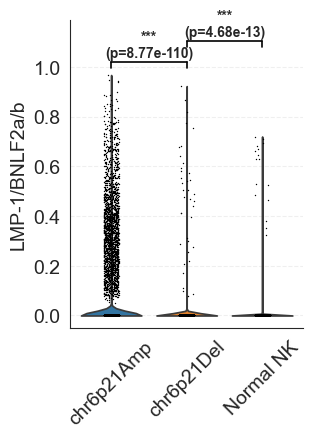

In [916]:
fig, ax = plt.subplots(1, 1, figsize=(3, 4))
comparisons = [('MaligNK_chr6p21Amp', 'MaligNK_chr6p21Del'), ('MaligNK_chr6p21Del', 'Normal NK')]
ax, stat, method = plot_violin_stats(
    adata=adata_exter_NK,
    gene='LMP-1/BNLF2a/b',
    groupby='anno-cnv',
    ax=ax,
    jitter=0.4,
    comparisons=comparisons,
)
ax.set_xlabel('')
ax.set_xticklabels(['chr6p21Amp', 'chr6p21Del', 'Normal NK'], rotation=45)
fig.savefig(f"{figPath}/FigS4g.png", dpi=400, bbox_inches='tight')
print_stat(stat, method)